# Tarea 2: Backpropagation, descenso de gradiente y entrenamiento <br/> CC6204 Deep Learning, Universidad de Chile 

**Fecha de entrega: 6 de Septiembre de 2026 **

En esta tarea programarás una red neuronal y definiras modulos relevantes como funcion de entropia y modulos de normalizacion.

Te recomendamos que repases la materia de las clases de redes neuronales y :
* [Redes neuronales](https://www.u-cursos.cl/ingenieria/2026/2/CC6204/1/material_docente/detalle?id=10896421)
* [Regularizacion](https://www.u-cursos.cl/ingenieria/2026/2/CC6204/1/material_docente/detalle?id=10896421)

También puedes revisar estos material complementario:
* [Slides Back-propagation](https://fleuret.org/dlc/materials/dlc-slides-3-6-backprop.pdf)
* [Slides Batch-Normalization](https://fleuret.org/dlc/materials/dlc-slides-6-4-batch-normalization.pdf)


IMPORTANTE: A menos que se exprese lo contrario, sólo podrás utilizar las clases y funciones en el módulo [`torch`](https://pytorch.org/docs/stable/torch.html).

Para esta tarea se recomienda el uso de las funciones:
- torch.log2
- torch.exp
- torch.abs
- torch.sum
- torch.mean
- torch.pow
- torch.zeros,torch.empty,torch.arange y otros constructores.

(por Luis Cossio, [https://github.com/luisCossio](https://github.com/luisCossio/CC6204-Deep-Learning))

In [28]:
# Este notebook está pensado para correr en CoLaboratory.
import torch
from tqdm import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn import functional as F

from PIL import Image
from torch import nn,save,load
from torch.optim import SGD
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## Parte 1: Probabilidades, Información y Entropía
La función de información de Shannon se define como una función de una probabilidad:
$$
I(p_i) = -log_2(p_i)
$$
1. Grafique la función para $p_i \epsilon (0,1) $ y describa su comportamiento.  ¿Qué significa una información Nula?
Se define la entropía de una probabilidad como:
$$
H(p_i) = -log_2(p_i) p_i
$$
2. Grafique la función para $p_i \epsilon (0,1) $ y describa su comportamiento.  Que significa que un evento probabilidad 0.0 o probabilidad 1.0, de ocurrir.

3. Dada una serie de predicciones binarias y sus respectivas clases reales se define la entropía cruzada entre predicción y GT como:
$$
H(p_i,\overline{y}_i) = - y_i log_2(p_i) - (1 - y_i) log(1 - p_i)
$$
4. Dadas las siguientes probabilidades calcule la entropía cruzada. En este contexto $p_i$ = 1.0 significa una confianza absoluta de pertenecer a la clase positiva, y $p_i$=0.0, significa una confianza absoluta de pertenecer a la clase negativa.

```python
y = [0,0,1,1]
y_pred = [0.99,0.01,0.99,0.01]
```

Es útil que la misma probabilidad tenga distintas entropías?


## Parte 2: Función de costo de entropía cruzada para la predicción multi-clase.
1. Defina la función de activación Softmax.
$$
 Softmax(p, p_i) = \frac{e^{p_i}}{\sum_{j=0}^{N_{classes}}e^{p_j}}
$$
2. Defina una clase CELoss que hereda de nn.Module, y que recibe logits $z_i \epsilon \mathbb{R}^{Batch-size,N_{classes}}$ & labels one-hot y retorne la función de entropía multi clase. Para ello:
- Defina una función que recibe labels $y_i ={0, 1, \cdots , N_{classes}}$ y genera un one-hot encoding
```
labels = [0,4,1]
labels_onehot =
|  1,0,0,0,0,0,0,0,0,0 |
|  0,0,0,0,1,0,0,0,0,0 |
|  0,1,0,0,0,0,0,0,0,0 |

```
Se define la entropía cruzada entre una clase $y_{i,j}$ y prediccion $\overline{y}_{i,j}$:
<br>
\begin{equation}
\it{CE}(y_i,\overline{y}_{i})=\sum_{j=0}^{N_{classes}-1}y_{i,j}\log \bigg(\frac{1}{\overline{y}_{i,j}}\bigg)=- \sum_{j=0}^{N_{classes}-1}y_{i,j}\log \overline{y}_{i,j}
\end{equation}
<br>
donde $y_{i,j}$ es la codificacion one-hot para la clase real.
- Programar la clase `CELoss` que recibe tensores $y_{ij}$ y $P_{ij}$ (de las mismas dimensiones) y calcula el promedio de las entropías cruzadas de las distribuciones $y_i$ y $\overline{y}_i$ de la siguiente forma
<br>
\begin{equation}
\it{CELoss}(Q,P)=\frac{1}{N}\sum_{i}\it{CE}(y_{i}, \overline{y}_{i})
\end{equation}
<br>
Valide los resultados de input y output con la función test_loss_function.


In [17]:
def test_loss_function(model_loss, dim_output):
    batch_size = 23
    x = torch.rand([batch_size,dim_output])
    # Forward pass
    y = torch.randint(0,2,(batch_size,dim_output))
    out = model_loss(y, x)
    assert (out.min() > 0),f"Error invalid value reached {out.min()}"
    x = torch.tensor([[10,-10,-10,-10,-10,-10,-10,-10,-10,-100]])
    y = torch.tensor([[1,0,0,0,0,0,0,0,0,0]])
    out = model_loss(y, x)
    assert (out < 0.1),f"Error entropy value for logits correct produce {out} instead of ~0.0"
    print("Successfull check")
    return True


def softmax(x: torch.Tensor):
    ### CODE HERE



class CELoss:
    def __init__(self, stable:bool =True, epsilon:float =1e-8,):
        self.stable = stable
        self.epsilon = epsilon

    def __call__(self, y_onehot: torch.Tensor, y_logits: torch.Tensor):
        ### CODE HERE


def one_hot_encoding(y_labels, n_classes):
    ### CODE HERE

n_classes = 10
loss_fn = CELoss()
success = test_loss_function(loss_fn, n_classes)


Successfull check


In [3]:
class telefono:
    def __init__(self,):
        pass

    def __call__(self,):
        print("Alo Alo!")
        
    def __call__(self,x):
        print("Alo Alo2!")
a = telefono()
a(1)

Alo Alo2!


## Parte 3: Batch normalization
Defina un módulo que realice el cálculo de mini batches. Para ello defina una clase que guarda los valores de promedio y de varianza de los tensores que pasen el. Recuerde la normalización por mini batches se calcula como:
$$
\hat{x} = \frac{x-\mu}{\sqrt{\sigma^2 + \epsilon}}
$$



In [44]:
class BatchNormalization:
    def __init__(self, hidden_dim:int,epsilon:float=0.0001, momentum:float=0.9):
        ### CODE HERE

    def __call__(self,x:torch.Tensor):
        ### SE  RECOMIENDA USAR LA FUNCION .detach(), en mean y variance antes de normalizar.
        ### CODE HERE


def test_batch_normalization():
    batch = BatchNormalization(10)
    for i in range(100):
        x = torch.rand(32,10)
        out = batch(x)

    assert torch.abs(torch.mean(out)) < 0.1, "Update of normalization failed. Too big values"
    assert out.size()==x.size(), "Inconsistent dims"
    print("Successfull check")
    return True

success = test_batch_normalization()

Successfull check


## Parte 4: Entrenamiento y evaluación.
Ahora se va a realizar un entrenamiento de una red multi-clase de multiples capas ocultas. Utilice la clase nn.Module para generar las redes.
1. Explore los datos de la base MNIST, y defina una función que re-orden de un batch de dimensiones [batch_size, 28, 28] - > [batch_size, 784]
2. Defina una red que tenga múltiples capas ocultas Feed Forward y función de activación ReLU.
3. Defina una red que incorpore su módulo de batch-normalization.
4. Realice un entrenamiento con cada red. Guarde datos de accuracy y loss.
5. Defina una funcion evaluate que reciba el dataloader de validacion, y genere metricas de accuracy, loss y matriz de confusion.
6. Identifique 5-10 imágenes donde haya habido un error de predicción, y grafíquelas.


In [45]:
# Loading Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize( (0.5,), (0.5,) )])
train_dataset = datasets.MNIST(root="data", download=True, train=True, transform=transform)
val_dataset = datasets.MNIST(root="data", download=True, train=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)



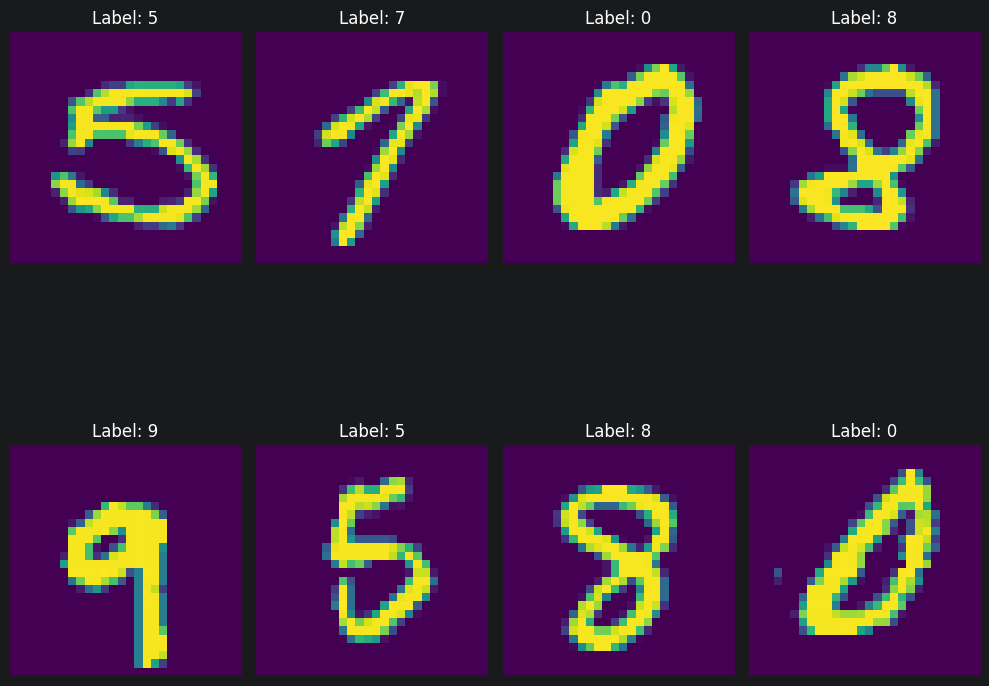

In [46]:

def plot_rand_samples(dataset, n_samples=4):
    # batch of random samples
    images, labels = next(iter(dataset))

    # plot
    n_rows = max(n_samples//4,1)
    if n_rows > 1:
        fig, axes = plt.subplots(n_rows, 4, figsize=(10, 10))

        for i in range(n_samples):
            y = i //4 # the row number
            x = i % 4  # the col number
            ax = axes[y, x]
            ax.imshow(images[i].squeeze(), cmap='viridis')
            ax.set_title(f"Label: {labels[i].item()}")
            ax.axis("off")
    else:
        fig, axes = plt.subplots(1, 4, figsize=(10, 10))

        for i in range(n_samples):

            x = i % 4  # the col number
            ax = axes[x]
            ax.imshow(images[i].squeeze(), cmap='viridis')
            ax.set_title(f"Label: {labels[i].item()}")
            ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_rand_samples(train_loader, n_samples=8)

In [47]:

class FeedForwardNet(nn.Module):
    """Basic feedforward network: 3 hidden layers with ReLU activation."""

    def __init__(self, input_features:int=24, hidden_features:list[int]=[32, 64, 128], output_features:int=2):
        super(FeedForwardNet, self).__init__()
        ### CODE HERE

    def forward(self, x):
        ### CODE HERE


class FeedForwardNormalizedNet(nn.Module):
    """Basic feedforward network: 3 hidden layers with ReLU activation and batch normalization."""

    def __init__(self, input_features:int=24, hidden_features:list[int]=[32, 64, 128], output_features:int=2):
        super(FeedForwardNormalizedNet, self).__init__()
        ### CODE HERE

    def forward(self, x):
        ### CODE HERE

def flat_data(x: torch.Tensor):
    ### CODE HERE


In [41]:
# Create an instance of the image classifier model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [51]:
lr = 0.001
classifier = FeedForwardNormalizedNet(28*28 , [64,128, 256],output_features=n_classes).to(device)
optimizer = SGD(classifier.parameters(), lr=lr)
loss_fn = CELoss()

# Train the model
epochs = 10
loss_epochs = ### CODE HERE
accuracy_epochs = ### CODE HERE
for epoch in tqdm(range(epochs)):
    loss_epoch = ### CODE HERE
    accuracy_epoch = ### CODE HERE
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images_flatten = flat_data(images)
        optimizer.zero_grad()  # Reset gradients
        outputs = classifier(images_flatten)  # Forward pass
        labels_one_hot = one_hot_encoding(labels, n_classes)
        loss = loss_fn(labels_one_hot, outputs)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        loss_epoch ### CODE HERE
        accuracy_epoch ### CODE HERE

    ### CODE HERE



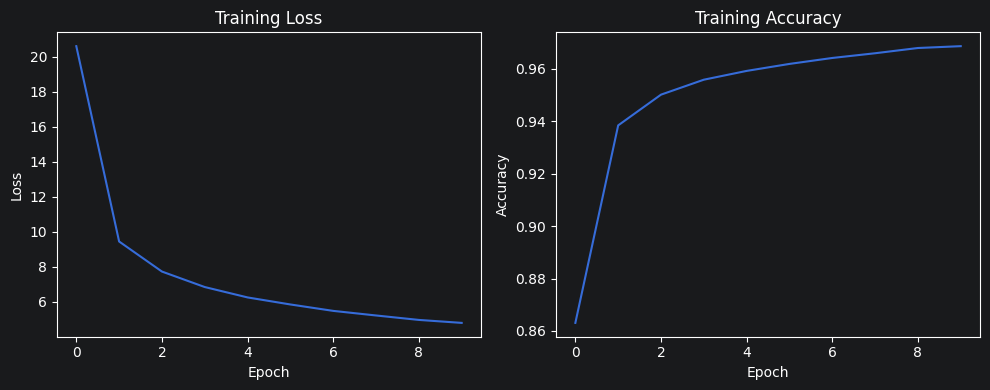

In [50]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(10, 4))
# loss_eval, accuracy_eval, confusion_matrix = evaluate(eval_loader, classifier, n_classes, device,loss_fn)
ax_loss.plot(loss_epochs)
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.set_title('Training Loss')
ax_acc.plot(accuracy_epochs)
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')
ax_acc.set_title('Training Accuracy')
plt.tight_layout()
plt.show()


## Parte 5: Análisis
1. ¿Qué tipo de red presentó mejores resultados?
2. ¿Como se comportaron las metricas de validacion con respecto a las metricas de entrenamiento?
3. Al variar algún hiper-parámetro ¿noto si alguna de las redes tenia peor o mejor rendimiento?
4. ¿Que patrones observa en la matriz de confusión?
5. ¿Que se puede concluir de números incorrectamente asignados?
6. Considere este escenario: Se calculo la entropia promedio para cada clase, ¿que se podria inferir de estos datos?
```
|          | 0    | 1    | 2    | 3    | 4    | 5    | 6    | 7    | 8    | 9    |
|----------|------|------|------|------|------|------|------|------|------|------|
| Entropia | 0.44 | 0.75 | 0.51 | 0.22 | 0.39 | 0.19 | 0.44 | 0.72 | 0.49 | 0.   |
```